# Trees and Ensembles — Titanic Survival Prediction

This notebook builds decision tree and ensemble classifiers for the Titanic dataset.

Each row represents a passenger, and the target is whether the passenger survived.

## Goals

Walk through a complete classification workflow:

- Load the data
- Clean and prepare features
- Perform quick exploratory data analysis
- Split the data
- Fit a single decision tree
- Compare tree-based ensemble models
- Interpret feature importances

Evaluate the classifiers using:

- Test accuracy
- Cross-validation accuracy
- Model comparison table
- Decision tree visualization
- Random Forest feature importances

Compare a single decision tree against Random Forest and Gradient Boosting models.

## Dataset

- Source: Titanic dataset
- Original size: 891 passengers
- Features used in this notebook:
  - Passenger class
  - Sex
  - Age
  - Number of siblings/spouses aboard
  - Number of parents/children aboard
  - Fare
  - Embarked location indicators

## Target

- The target is binary:
  - `0` = died
  - `1` = survived

In [9]:
import os
import urllib.request

DATA_DIR = os.path.join(os.path.dirname(os.getcwd()), "data") if os.path.basename(os.getcwd()) == "notebooks" else "data"

os.makedirs(DATA_DIR, exist_ok=True)

def download_if_needed(url, filename):
    """Download a CSV if it doesn't already exist locally."""
    path = os.path.join(DATA_DIR, filename)
    if not os.path.exists(path):
        print(f"Downloading {filename} from {url}")
        urllib.request.urlretrieve(url, path)
    return path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report

sns.set_style("whitegrid")
np.random.seed(42)

## 1. Load data

In [10]:
path = download_if_needed(
    "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv",
    "titanic.csv",
)

df = pd.read_csv(path)

print("Shape:", df.shape)

df.head()

Shape: (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## 2. Light cleaning + feature engineering

In [11]:
work = df.copy()

# Encode "Sex" as a binary feature (1 = female, 0 = male)
work["Sex"] = (work["Sex"] == "female").astype(int)

# Fill missing ages with the median rather than dropping rows (~20% would be lost)
work["Age"] = work["Age"].fillna(work["Age"].median())

# Embarkation port: only 2 missing values, default to most common ("S" = Southampton)
work["Embarked"] = work["Embarked"].fillna("S")

# One-hot encode "Embarked" into binary columns. drop_first avoids redundancy.
work = pd.get_dummies(work, columns=["Embarked"], drop_first=True)

feature_cols = [
    "Pclass",
    "Sex",
    "Age",
    "SibSp",
    "Parch",
    "Fare",
    "Embarked_Q",
    "Embarked_S",
]

work = work[feature_cols + ["Survived"]].dropna()

print("Cleaned shape:", work.shape)

work.head()

Cleaned shape: (891, 9)


,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_Q,Embarked_S,Survived
0,3,0,22.0,1,0,7.2500,False,True,0
1,1,1,38.0,1,0,71.2833,False,False,1
2,3,1,26.0,0,0,7.9250,False,True,1
3,1,1,35.0,1,0,53.1000,False,True,1
4,3,0,35.0,0,0,8.0500,False,True,0


## 3. Quick EDA: survival by sex and class

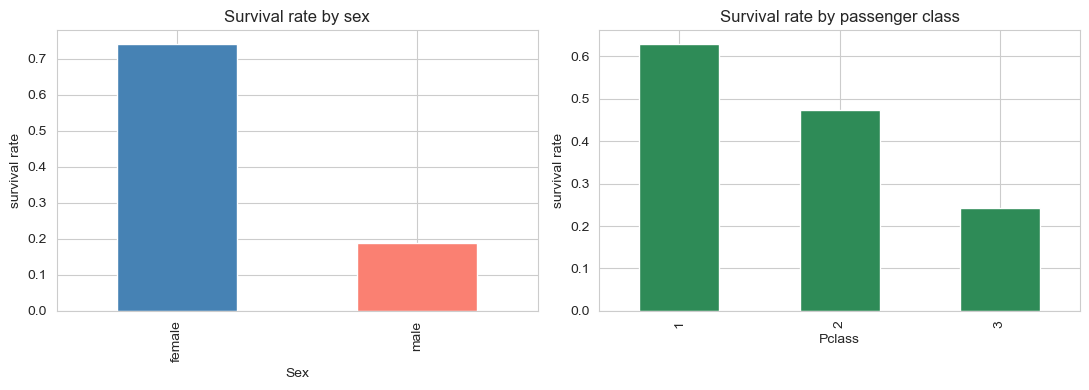

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

df.groupby("Sex")["Survived"].mean().plot(
    kind="bar",
    ax=axes[0],
    color=["steelblue", "salmon"],
)
axes[0].set_title("Survival rate by sex")
axes[0].set_ylabel("survival rate")

df.groupby("Pclass")["Survived"].mean().plot(
    kind="bar",
    ax=axes[1],
    color="seagreen",
)
axes[1].set_title("Survival rate by passenger class")
axes[1].set_ylabel("survival rate")

plt.tight_layout()
plt.show()

Sex and class are by far the strongest predictors — women and first-class passengers were much more likely to survive.

## 4. Split

In [13]:
X = work[feature_cols].values
y = work["Survived"].values

X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

## 5. Single decision tree (depth 3 — for visualization)

Test accuracy: 0.7848


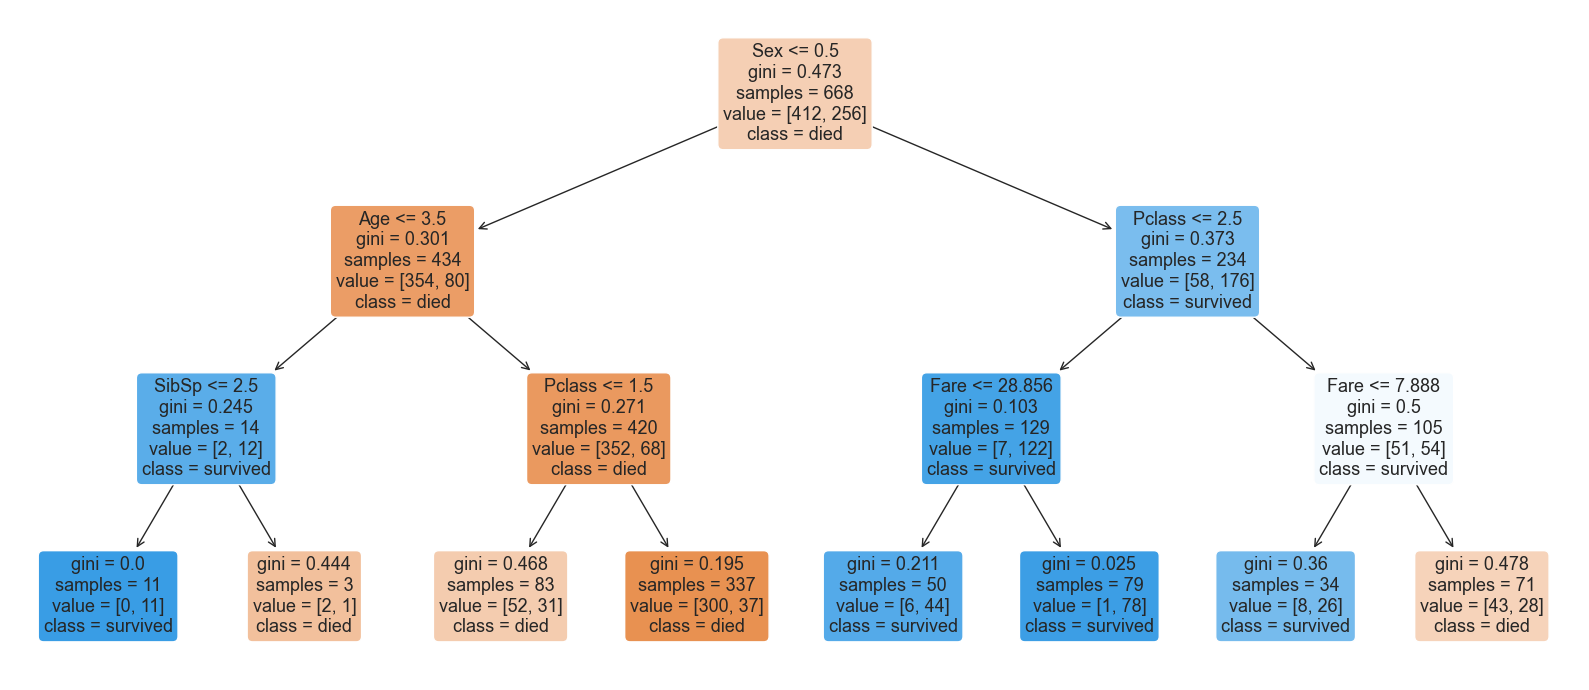

In [14]:
tree = DecisionTreeClassifier(max_depth=3, random_state=42).fit(X_tr, y_tr)

print(f"Test accuracy: {accuracy_score(y_te, tree.predict(X_te)):.4f}")

plt.figure(figsize=(16, 7))
plot_tree(
    tree,
    feature_names=feature_cols,
    class_names=["died", "survived"],
    filled=True,
    rounded=True,
)

plt.tight_layout()
plt.show()

## 6. Compare three models

In [15]:
# Three increasingly sophisticated tree-based models:
models = {
    # Single tree, depth-limited to prevent overfitting
    "Decision Tree":     DecisionTreeClassifier(max_depth=5, random_state=42),

    # Bagging: 200 trees trained on bootstrapped samples; predictions averaged → reduces variance
    "Random Forest":     RandomForestClassifier(n_estimators=200, random_state=42),

    # Boosting: 200 trees trained sequentially, each correcting predecessors → reduces bias
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=200, random_state=42),
}


rows = []

for name, m in models.items():
    m.fit(X_tr, y_tr)

    cv = cross_val_score(m, X_tr, y_tr, cv=5).mean()
    test_acc = accuracy_score(y_te, m.predict(X_te))

    rows.append({"Model": name, "CV acc": cv, "Test acc": test_acc})

pd.DataFrame(rows).round(4)

,Model,CV acc,Test acc
0,Decision Tree,0.8129,0.7668
1,Random Forest,0.8309,0.7668
2,Gradient Boosting,0.8428,0.7937


## 7. Feature importances (Random Forest)

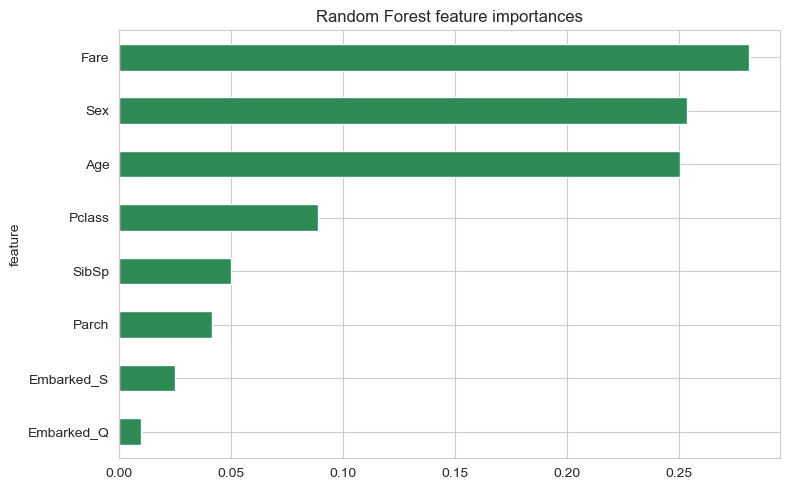

In [16]:
rf = models["Random Forest"]

imp = pd.DataFrame(
    {
        "feature": feature_cols,
        "importance": rf.feature_importances_,
    }
).sort_values("importance")

imp.plot.barh(
    x="feature",
    y="importance",
    figsize=(8, 5),
    legend=False,
    color="seagreen",
)

plt.title("Random Forest feature importances")

plt.tight_layout()
plt.show()

## Takeaways

- A simple depth-3 decision tree already captures the major survival patterns in the Titanic data, especially splits involving `Sex`, `Pclass`, and `Age`.

- The single depth-3 tree reaches 0.7848 test accuracy, showing that even a small interpretable tree can perform reasonably well.

- In the model comparison, Gradient Boosting performs best on the test set with 0.7937 accuracy. The Decision Tree and Random Forest both reach 0.7668 test accuracy.

- Random Forest uses bagging: it builds many decorrelated trees and averages them to reduce variance.

- Gradient Boosting builds trees sequentially, where each new tree tries to correct the mistakes of the previous ones. In this notebook, it gives the strongest overall test performance.

- The Random Forest feature importance plot shows that `Fare`, `Sex`, and `Age` are the most important predictors, followed by `Pclass`.

- Tree-based methods do not require feature scaling, which is why no `StandardScaler` is used in this notebook.